# EDA and Text Preprocessing - Urgency Classification

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Styling for plots
sns.set_theme(style="whitegrid")

## 1. Load Data

In [31]:
df = pd.read_csv('../data/raw/complaints-2026-05-20_09_21.csv')
print(f"Shape of dataset: {df.shape}")
df.head(2)

Shape of dataset: (53928, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,03/17/26,Debt collection,Auto debt,Written notification about debt,Didn't receive notice of right to dispute,I started getting emails and telephone calls from this company called the bureaus telling me I owe over {$8000.00} for a past automobile that was repossessed. The lender at the time told me I did not owe anything and they would just report the underwater amount to the credit bureaus. They told me they would not send to collections.,NaN,"The Bureaus, Inc.",GA,30518,NaN,Consent provided,Web,03/17/26,Closed with explanation,Yes,NaN,20323715
1,03/05/26,Debt collection,Other debt,False statements or representation,Attempted to collect wrong amount,"Date : XX/XX/XXXX To : XXXX XXXX Re : XXXXXXXX XXXX XXXX Ref XXXX XXXX BAL : {$1000.00} XXXX XXXX XXXXXXXX EP AUDIT RE : Continued Contact After Cease and Desist Notice of Intent to Pursue Legal Action XXXX XXXX, This letter serves as formal notice that your continued attempts to contact me after receiving a written Cease and Desist demand dated XX/XX/XXXX constitute unlawful and unwanted communication. \n\n\n\nIn that correspondence you were clearly advised of the following : I separated from the company in question. \nThe company has not been operational since XX/XX/XXXX. \nI am not an owner, operator, XXXX, or responsible party for the company. \nI have no authority to act on behalf of that business. \nAll further contact directed toward me regarding that company must cease immediately. \n\n\n\n\nDespite receiving that notice, you proceeded to continue contacting me in direct violation of that demand. Specifically : XXXX additional emails sent on XX/XX/XXXX XXXX phone calls made on XX/XX/XXXX Additional contact attempts made again on XX/XX/XXXX These actions constitute knowing and repeated unwanted contact. \n\n\n\nUnder XXXX XXXX, a person commits harassment if they intentionally harass or annoy another person through repeated unwanted contact. Continuing communication after a clear demand to cease contact is evidence of intentional harassment. \n\n\n\nAdditionally, Oregon law recognizes civil liability for persistent unwanted contact and interference with personal privacy and peace. Oregon courts have held that repeated unwanted communications after notice to stop may support claims including : Harassment Invasion of privacy Intentional infliction of emotional distress See XXXX XXXX XXXX recognizing civil liability where conduct intentionally intrudes upon anothers protected interests after clear notice. \n\n\n\nYour continued communications also demonstrate a disregard for a lawful written demand to cease contact with a non-related private individual, which further establishes the willful nature of the conduct. \n\n\n\nAccordingly, you are hereby placed on final notice of the following : I am not affiliated with the company referenced in your communications. \nI have no authority or obligation regarding that business or its insurance matters. \nAll future communications regarding that company must be directed to the company itself or its legal representative. \nYou are to immediately cease all communication with me. \n\n\n\n\nIf any further contact occurs after receipt of this letter, I will pursue all available legal remedies, including filing a civil action seeking : Injunctive relief Monetary damages Attorney fees Any other relief the court deems appropriate All continued communications are being documented and preserved as evidence. \n\n\n\nThis letter serves as a final opportunity to comply voluntarily before legal action is initiated. \n\n\n\nGovern yourself accordingly. \n\n\n\nSincerely, XXXX XXXX",NaN,"CAINE & WEINER COMPANY, INC.",OR,973XX,NaN,Consent provided,Web,03/19/26,Closed with non-monetar

## 2. Pembersihan Data Awal
Menghapus baris jika:
1. `Consumer complaint narrative` kosong (NaN).
2. `Consumer complaint narrative` hanya berisi karakter aneh atau panjang katanya kurang dari 3 kata.

In [32]:
# Drop NaN on Narrative
df = df.dropna(subset=['Consumer complaint narrative']).copy()

# Fungsi untuk menghitung kata
def count_words(text):
    if not isinstance(text, str):
        return 0
    # Hapus karakter non-alfanumerik agar tidak dihitung sebagai kata
    clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    words = clean_text.strip().split()
    return len(words)

df['Word Count'] = df['Consumer complaint narrative'].apply(count_words)

# Drop baris dengan kurang dari 3 kata
df = df[df['Word Count'] >= 3]

print(f"Shape of dataset after dropping empty/short narratives: {df.shape}")

Shape of dataset after dropping empty/short narratives: (53928, 19)


## 3. Data Labeling (Rule-Based Hierarchical)
Membuat label `Urgency` (High, Medium, Low) sesuai instruksi (Hierarki Prioritas):
- **High**: Dicek pertama kali. Jika Narrative mengandung keyword High ATAU Issue mengandung Issue High.
- **Medium**: Dicek kedua. Jika tidak High, dan Narrative mengandung keyword Medium ATAU Issue mengandung Issue Medium.
- **Low**: Jika tidak memenuhi kedua kondisi di atas (Default ke Low).

In [33]:
high_issues = [
    "Fraud or scam",
    "False statements or representation",
    "Threatened to contact someone or share information improperly",
    "Took or threatened to take negative or legal action",
    "Improper use of your report",
    "Unauthorized transactions or other transaction problem",
    "Unauthorized withdrawals or charges",
    "Credit monitoring or identity theft protection services",
    "Problem with fraud alerts or security freezes",
    "Received a loan you didn't apply for",
    "Lost or stolen money order",
    "Repossession",
    "Vehicle was repossessed or sold the vehicle",
    "Vehicle was damaged or destroyed the vehicle"
]

high_keywords = [
    'stolen', 'harassing', 'illegal', 'threatened', 'victim of identity theft', 
    'scam', 'fraud', 'unauthorized', 'legal action', 'police report',
    'hacked',            
    'breach',            
    'forged',            
    'impersonating',     
    'fake account',      
    'stole',            
    'extortion',         
    'attorney',          
    'lawsuit',           
    'sue',               
    'abusive',           
    'harassment'         
]


medium_issues = [
    "Attempts to collect debt not owed",
    "Incorrect information on your report",
    "Problem with a purchase shown on your statement",
    "Fees or interest",
    "Charged fees or interest you didn't expect",
    "Unexpected or other fees",
    "Charged upfront or unexpected fees",
    "Unexpected fees",
    "Wrong amount charged or received",
    "Money was taken from your bank account on the wrong day or for the wrong amount",
    "Problem with a lender or other company charging your account",
    "Struggling to pay your loan",
    "Struggling to pay mortgage",
    "Struggling to repay your loan",
    "Struggling to pay your bill",
    "Problem when making payments",
    "Trouble during payment process",
    "Loan payment wasn't credited to your account",
    "Issues with repayment",
    "Problem caused by your funds being low",
    "Money was not available when promised",
    "Was approved for a loan, but didn't receive the money",
    "Problems receiving the advance",
    "Problem with a company's investigation into an existing problem",
    "Problem with a purchase or transfer",
    "Didn't provide services promised",
    "Problem with overdraft",
    "Problem with cash advance",
    "Can't stop withdrawals from your bank account",
    "Can't contact lender or servicer",
    "Unable to get your credit report or credit score",
    "Incorrect exchange rate"
]

medium_keywords = [
    'incorrect', 'error', 'dispute', 'charged', 'wrong amount', 'late fee', 
    'inaccurate', 'validation', 'verification', 'investigation', 'discrepancy', 'charge',
    'overcharged',          
    'double charged',       
    'refund',               
    'penalty',              
    'missing payment',      
    'misapplied',           
    'credit score dropped', 
    'balance error',        
    'never received',       
    'refused to correct',   
    'unresolved',           
    'adjustment'            
]

low_issues = [
    "Written notification about debt",
    "Managing the loan or lease",
    "Getting a loan or lease",
    "Getting the loan",
    "Getting a loan",
    "Closing an account",
    "Closing your account",
    "Opening an account",
    "Managing an account",
    "Getting a credit card",
    "Getting a line of credit",
    "Applying for a mortgage or refinancing an existing mortgage",
    "Closing on a mortgage",
    "Managing, opening, or closing your mobile wallet account",
    "Problem getting a card or closing an account",
    "Trouble using the card",
    "Trouble using your card",
    "Trouble accessing funds in your mobile or digital wallet",
    "Other transaction problem",
    "Other features, terms, or problems",
    "Other service problem",
    "Problem with customer service",
    "Problem adding money",
    "Dealing with your lender or servicer",
    "Electronic communications",
    "Communication tactics",
    "Confusing or missing disclosures",
    "Advertising and marketing, including promotional offers",
    "Confusing or misleading advertising or marketing",
    "Advertising",
    "Problem with additional add-on products or services",
    "Problem with the payoff process at the end of the loan",
    "Problems at the end of the loan or lease",
    "Issue with income share agreement",
    "Issue where my lender is my school",
    "Overdraft, savings, or rewards features",
    "Credit limit changed"
]

# def determine_urgency(row): 
#     issue = str(row['Issue']).strip()
#     narrative = str(row['Consumer complaint narrative']).lower()
#     if issue in high_issues or any(keyword in narrative for keyword in high_keywords):
#         return 'High'
#     if issue in medium_issues or any(keyword in narrative for keyword in medium_keywords):
#         return 'Medium' 
#     return 'Low'


def determine_urgency(row):
    issue = str(row['Issue']).strip()
    narrative = str(row['Consumer complaint narrative']).lower()
    
    # 1. Cek HIGH Prioritas Pertama
    # Menggunakan regex \b untuk memastikan pencarian kata utuh. Ini pakai regex untuk mengatasi class imbalance (fungsi aslinya ada di atas)
    if issue in high_issues or any(re.search(rf"\b{keyword}\b", narrative) for keyword in high_keywords): 
        return 'High'
    
    # 2. Cek MEDIUM Prioritas Kedua
    if issue in medium_issues or any(re.search(rf"\b{keyword}\b", narrative) for keyword in medium_keywords):
        return 'Medium'
    
    # 3. Sisanya LOW (Default Fail-Safe)
    return 'Low'

# Terapkan fungsi yang baru ke dataframe
df['Urgency'] = df.apply(determine_urgency, axis=1)

# Cek kembali distribusi kelasnya
print("Distribusi Urgency:")
print(df['Urgency'].value_counts())

Distribusi Urgency:
Urgency
Medium    26300
High      20771
Low        6857
Name: count, dtype: int64


In [34]:
pd.set_option('display.max_colwidth', None) 

print("=== CONTOH 5 DATA HIGH URGENCY ===")
sample_high = df[df['Urgency'] == 'High'].sample(5, random_state=42)
sample_high[['Issue', 'Consumer complaint narrative']]

=== CONTOH 5 DATA HIGH URGENCY ===


Issue  \
19568  Problem with additional add-on products or services   
21068                 Dealing with your lender or servicer   
12801                   False statements or representation   
38434                   False statements or representation   
34067                   False statements or representation   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [35]:
print("=== CONTOH 5 DATA MEDIUM URGENCY ===")
sample_medium = df[df['Urgency'] == 'Medium'].sample(5, random_state=42)
sample_medium[['Issue', 'Consumer complaint narrative']]

=== CONTOH 5 DATA MEDIUM URGENCY ===


,Issue,Consumer complaint narrative
37558,Problem with a lender or other company charging your account,"this person was pretending to be someone else who could help me out with some money, they texted me on telegram i thought it was legit. they told me to transfer XXXX dollars twice to therefore get money in return. after i did do that they never sent me money back and blocked my contact information. i really need this money, my bank doesnt want to help me they said i need to talk to the police. \n\ni have screenshot proof of when it happened, by who, how much and where. \n\nthe second transfer was on XX/XX/XXXX at XXXX pm to XXXX XXXX according to my bank this person is living in michigan the first transfer was made on XX/XX/XXXX XXXX for {$300.00} to XXXX XXXX, this person is living in michigan also. \n\nI dont know any of these people, i currently live in XXXX nebraska XXXX is there any way you all could help me recover this money back please"
50430,Attempts to collect debt not owed,Received a call from a ignorant irate over talking collector that said I owed {$500.00} and at this time it's {$850.00} to easy money and refused to provide the account number and other information purtaining to the false call then said my social security number and hung up.
6186,Unexpected fees,"I have never received any formal debt validation, supporting documentation, or itemized receipts from the company substantiating or verifying the legitimacy of this account. Despite the passage of time, no written evidence has been provided to demonstrate that this debt is valid, accurate, or legally enforceable. As such, I have not been given sufficient documentation to confirm the origin, amount, or authorization of the alleged obligation."
46184,Written notification about debt,"After receiving text message from RDAC on XX/XX/year> that our disputed debt with our apartment leasing office had been turned over to them for collections, I sent a certified, return receipt letter disputing this charge on XX/XX/year>. That letter was returned to sender, and received today ( XX/XX/year> ) and marked moved left no address unable to forward. This was sent within the 30-day window to dispute and request verification of the debt."
9748,Problem caused by your funds being low,"Wells Fargo Bank ( WF ) charged me XXXX overdraft fees of {$35.00} each in XX/XX/year>. I did not sign up for overdraft protection and they did not advise me of this when I opened the account. WF has opened many no-monthly fee accounts for students, making money on overdraft fees. On XX/XX/year> they charged me XXXX overdraft fees. On XX/XX/XXXX, they charged me XXXX overdraft fees. They do multiple charges for the same day. They made it very difficult to talk to someone at the bank. After several attempts, I met with a premier banker who told me that he can only credit me XXXX time $ XXXX, and therefore it would take me about a year and a half to get credit for everything. \n\nPlease investigate to ensure the bank refunds other students ' accounts for overdraft and other hidden fees."


In [36]:
print("=== CONTOH 5 DATA LOW URGENCY ===")
sample_low = df[df['Urgency'] == 'Low'].sample(5, random_state=42)
sample_low[['Issue', 'Consumer complaint narrative']]

=== CONTOH 5 DATA LOW URGENCY ===


,Issue,Consumer complaint narrative
3477,Communication tactics,"since XX/XX/XXXX, they have contacted me every single day. On XX/XX/XXXX, it was over text. from the XXXX until XX/XX/XXXX I have received an email from them every single day. on top of that, I have received multiple text messages, including one today at XXXX oclock in the morning on a Saturday. \n\nThe email that was sent on XX/XX/XXXX was also sent at XXXX XXXX. so was the one on XX/XX/XXXX. and XX/XX/XXXX!"
23898,Managing an account,"Dear Consumer Financial Protection Bureau, I am writing to urgently request your intervention in a deeply distressing and unjust situation involving my financial institutions. Without warning, explanation, or due process, my accounts were restricted, funds were reversed, my accounts were closed, and I have since been effectively blacklisted from opening new accounts. These actions have caused me severe financial harm and personal hardship. \n\nOn XX/XX/XXXX, I received a wire transfer of {$50000.00} into my Truist bank account. These funds were entirely legitimate, representing a business return on an investment I made using proceeds from the sale of my home. Relying on the availability of these cleared funds, I proceeded to make standard financial transactions, including a cashiers check withdrawal of {$39000.00}, which I deposited into my personal XXXX account. The funds cleared and were reflected in my available balance. I also transferred portions of these funds into cryptocurrency accounts as part of my investment strategy. \n\nShortly thereafter, and without any prior notice, my accounts were abruptly restricted. I lost access to my Truist and XXXX accounts, as well as my associated cryptocurrency accounts. Even more troubling, transactions that had already cleared were later reversed. These actions were taken unilaterally, with no explanation, no opportunity for me to respond, and no documentation provided to justify such severe measures. \n\nAs a direct result of these reversals, I now face a deficit of approximately {$7000.00} in my cryptocurrency accountan unexpected liability created solely by the actions of my financial institutions. This has compounded the financial damage I have already suffered. \n\nAdditionally, I have discovered that my name has been effectively blacklisted within the banking system, preventing me from opening new accounts elsewhere. This has left me financially stranded, unable to access basic banking services, and further exacerbates the harm caused. After everything I have endured, this continued restriction feels not only unjust, but punitive. \n\nThe impact of these actions on my life has been devastating. At XXXX XXXX XXXX, I depend on access to my funds for basic survival. I have been unable to pay for essential living expenses such as rent and utilities. During the cold month of XXXX, I was forced to live without electricity because I could not access my own money. The emotional and physical toll this has taken on me is difficult to overstate. \n\nDespite my repeated efforts to resolve this matterboth in person and through customer service channelsI have been met with dismissiveness and a lack of transparency. No one has provided me with a clear explanation for why my accounts were targeted, why my funds were reversed, or why such extreme actions were taken without due process. \n\nI respectfully assert that I have acted in good faith at all times and that the funds in question are legitimate. The treatment I have received raises serious concerns regarding fairness, transparency, and potential violations of my rights as a banking customer"
36618,Written notification about debt,This is not my debt i never opened this please get this off my credit report
42598,Trouble using your card,"On XX/XX/2025, Citi decreased my credit limit from {$21000.00} to {$16000.00}. I called on XX/XX/2025 and requested a reinstatement of my credit limit. Despite my request and multiple follow up on the status, Ci

## 4. Exploratory Data Analysis (EDA)
Melihat distribusi kelas dan distribusi panjang kata per kelas.

C:\Users\psdkp\AppData\Local\Temp\ipykernel_22172\1184275637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Urgency', data=df, order=['High', 'Medium', 'Low'], palette='viridis')


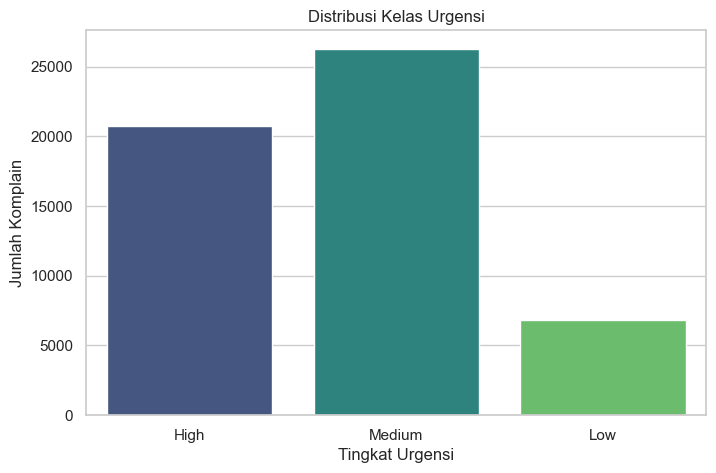

In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Urgency', data=df, order=['High', 'Medium', 'Low'], palette='viridis')
plt.title('Distribusi Kelas Urgensi')
plt.ylabel('Jumlah Komplain')
plt.xlabel('Tingkat Urgensi')
plt.show()

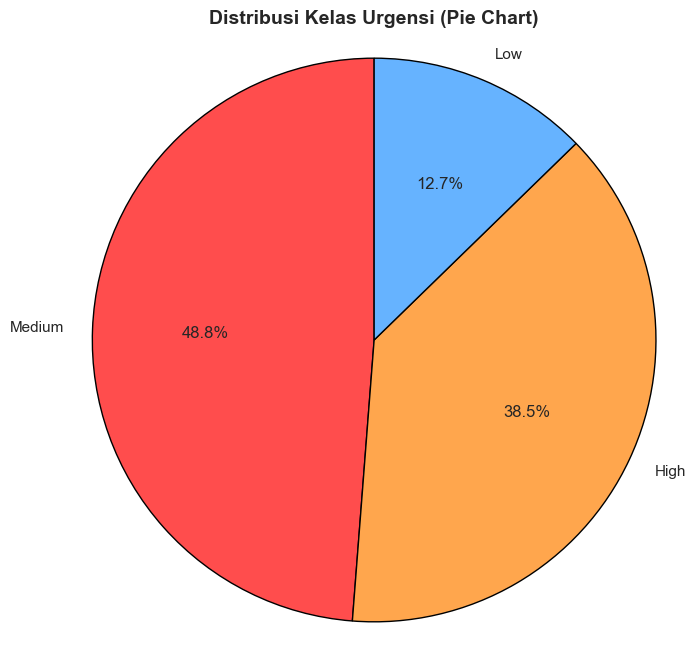

In [38]:
# Pie Chart Distribusi Kelas Urgensi
plt.figure(figsize=(8, 8))
class_counts = df['Urgency'].value_counts()
colors = ['#ff4d4d', '#ffa64d', '#66b3ff']
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Distribusi Kelas Urgensi (Pie Chart)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

C:\Users\psdkp\AppData\Local\Temp\ipykernel_22172\1069594578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Urgency', y='Word Count', data=df, order=['High', 'Medium', 'Low'], palette='Set2')


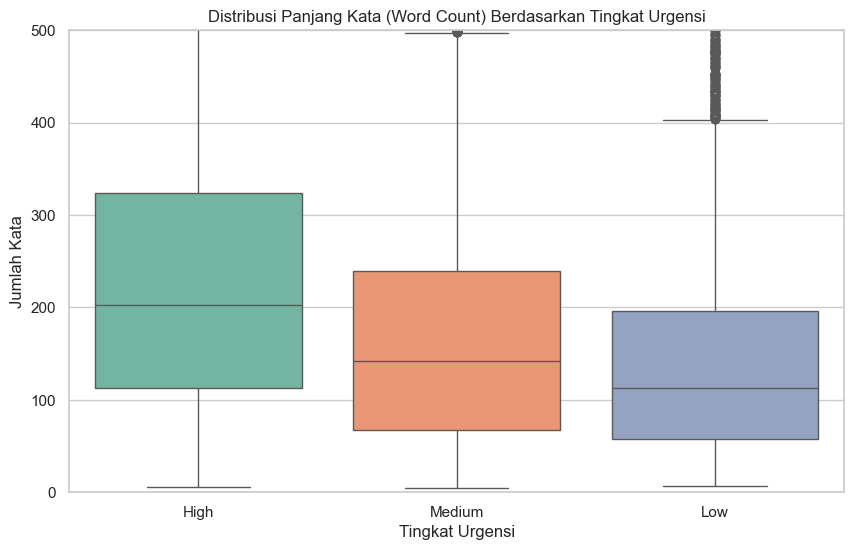

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Urgency', y='Word Count', data=df, order=['High', 'Medium', 'Low'], palette='Set2')
plt.title('Distribusi Panjang Kata (Word Count) Berdasarkan Tingkat Urgensi')
plt.ylim(0, 500) # Membatasi visualisasi outlier ekstrem agar lebih jelas 
plt.ylabel('Jumlah Kata')
plt.xlabel('Tingkat Urgensi')
plt.show()

## 5. Text Preprocessing
Membersihkan `Consumer complaint narrative` untuk persiapan *training* model Deep Learning.
Tahapan:
1. Lowercasing
2. Menghapus karakter anonimitas dari data CFPB (seperti `XXXX`, `XX/XX/XXXX`)
3. Menghapus tanda baca dan angka
4. Menghapus *stopwords*

In [40]:
nltk.download('wordnet')
nltk.download('stopwords')

# Tambahkan daftar kata negasi yang HARUS dipertahankan
words_to_keep = {'not', 'no', 'nor', "don't", "didn't", "doesn't", "isn't", "aren't", "wasn't", "weren't", "haven't", "hasn't", "cannot", "cant", "couldn't", "wouldn't", "shouldn't"}

# Buat custom stopwords dengan mengurangi kata negasi dari daftar bawaan NLTK
custom_stop_words = set(stopwords.words('english')) - words_to_keep

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
        
    # Lowercase
    text = text.lower()
    
    # Hapus mask 'xxxx' yang sering ada di dataset CFPB
    text = re.sub(r'x{2,}', '', text)
    
    # Hapus angka, karakter spesial/tanda baca
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Menghilangkan multiple spasi (whitespace)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Hapus stopwords
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in custom_stop_words]
    
    return ' '.join(words)

df['Cleaned_Narrative'] = df['Consumer complaint narrative'].apply(preprocess_text)

# Tampilkan perbandingan sebelum dan sesudah dibersihkan
df[['Consumer complaint narrative', 'Cleaned_Narrative', 'Urgency']].head(3)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\psdkp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\psdkp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Consumer complaint narrative,Cleaned_Narrative,Urgency
0,I started getting emails and telephone calls from this company called the bureaus telling me I owe over {$8000.00} for a past automobile that was repossessed. The lender at the time told me I did not owe anything and they would just report the underwater amount to the credit bureaus. They told me they would not send to collections.,started getting email telephone call company called bureau telling owe past automobile repossessed lender time told not owe anything would report underwater amount credit bureau told would not send collection,Low
1,"Date : XX/XX/XXXX To : XXXX XXXX Re : XXXXXXXX XXXX XXXX Ref XXXX XXXX BAL : {$1000.00} XXXX XXXX XXXXXXXX EP AUDIT RE : Continued Contact After Cease and Desist Notice of Intent to Pursue Legal Action XXXX XXXX, This letter serves as formal notice that your continued attempts to contact me after receiving a written Cease and Desist demand dated XX/XX/XXXX constitute unlawful and unwanted communication. \n\n\n\nIn that correspondence you were clearly advised of the following : I separated from the company in question. \nThe company has not been operational since XX/XX/XXXX. \nI am not an owner, operator, XXXX, or responsible party for the company. \nI have no authority to act on behalf of that business. \nAll further contact directed toward me regarding that company must cease immediately. \n\n\n\n\nDespite receiving that notice, you proceeded to continue contacting me in direct violation of that demand. Specifically : XXXX additional emails sent on XX/XX/XXXX XXXX phone calls made on XX/XX/XXXX Additional contact attempts made again on XX/XX/XXXX These actions constitute knowing and repeated unwanted contact. \n\n\n\nUnder XXXX XXXX, a person commits harassment if they intentionally harass or annoy another person through repeated unwanted contact. Continuing communication after a clear demand to cease contact is evidence of intentional harassment. \n\n\n\nAdditionally, Oregon law recognizes civil liability for persistent unwanted contact and interference with personal privacy and peace. Oregon courts have held that repeated unwanted communications after notice to stop may support claims including : Harassment Invasion of privacy Intentional infliction of emotional distress See XXXX XXXX XXXX recognizing civil liability where conduct intentionally intrudes upon anothers protected interests after clear notice. \n\n\n\nYour continued communications also demonstrate a disregard for a lawful written demand to cease contact with a non-related private individual, which further establishes the willful nature of the conduct. \n\n\n\nAccordingly, you are hereby placed on final notice of the following : I am not affiliated with the company referenced in your communications. \nI have no authority or obligation regarding that business or its insurance matters. \nAll future communications regarding that company must be directed to the company itself or its legal representative. \nYou are to immediately cease all communication with me. \n\n\n\n\nIf any further contact occurs after receipt of this letter, I will pursue all available legal remedies, including filing a civil action seeking : Injunctive relief Monetary damages Attorney fees Any other relief the court deems appropriate All continued communications are being documented and preserved as evidence. \n\n\n\nThis letter serves as a final opportunity to comply voluntarily before legal action is initiated. \n\n\n\nGovern yourself accordingly. \n\n\n\nSincerely, XXXX XXXX",date ref bal ep audit continued contact cease desist notice intent pursue legal action letter serf formal notice continued attempt contact receiving written cease desist demand dated constitute unlawful unwanted communication correspondence clearly advised following separated company question company not operational since not owner operator responsible party company no authority act behalf business contact directed toward 

## 6. EDA (NLP Insights)

### Analisis N-Gram (Bigram)

Memproses Bigram Analysis...


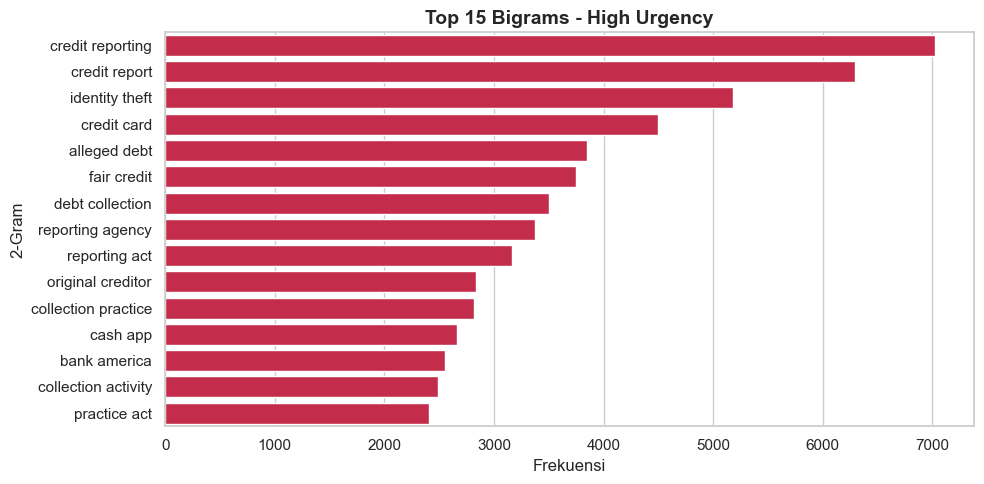

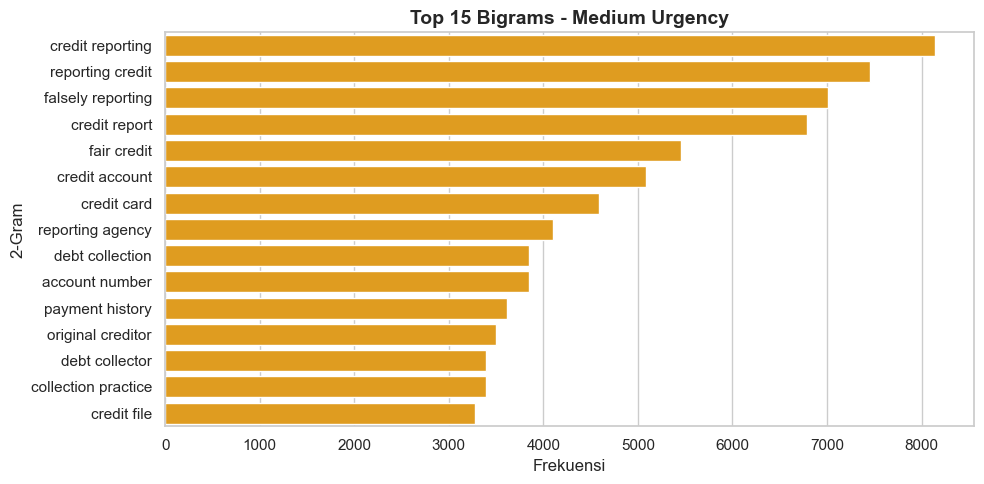

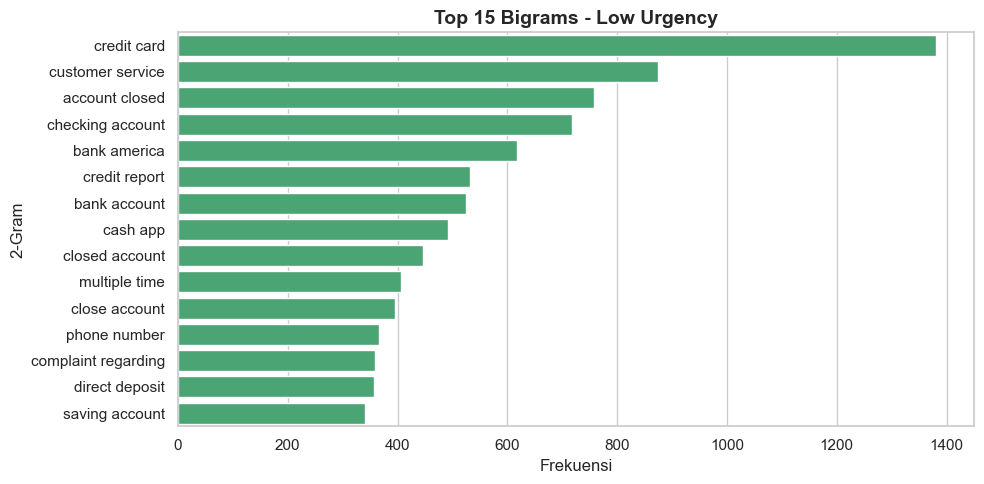

In [41]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Fungsi untuk mengekstrak dan memplot top N-Grams
def plot_top_ngrams(text_series, n, title, color):
    # Inisialisasi CountVectorizer untuk N-Gram (n=2 untuk Bigram)
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(text_series)
    bag_of_words = vec.transform(text_series)
    sum_words = bag_of_words.sum(axis=0) 
    
    # Mengurutkan frekuensi kata dari yang tertinggi
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:15]
    
    # Membuat DataFrame untuk visualisasi
    df_ngram = pd.DataFrame(words_freq, columns=['N-Gram', 'Frekuensi'])
    
    # Plotting menggunakan Seaborn
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Frekuensi', y='N-Gram', data=df_ngram, color=color)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Frekuensi', fontsize=12)
    plt.ylabel(f'{n}-Gram', fontsize=12)
    plt.tight_layout()
    plt.show()

# Memisahkan data berdasarkan kelas urgensi
high_texts = df[df['Urgency'] == 'High']['Cleaned_Narrative']
medium_texts = df[df['Urgency'] == 'Medium']['Cleaned_Narrative']
low_texts = df[df['Urgency'] == 'Low']['Cleaned_Narrative']

# Mengeksekusi fungsi untuk masing-masing kelas (Bigram / 2 kata)
print("Memproses Bigram Analysis...")
plot_top_ngrams(high_texts, 2, 'Top 15 Bigrams - High Urgency', 'crimson')
plot_top_ngrams(medium_texts, 2, 'Top 15 Bigrams - Medium Urgency', 'orange')
plot_top_ngrams(low_texts, 2, 'Top 15 Bigrams - Low Urgency', 'mediumseagreen')

### Word Cloud Tingkat Urgensi

Memproses Word Cloud...


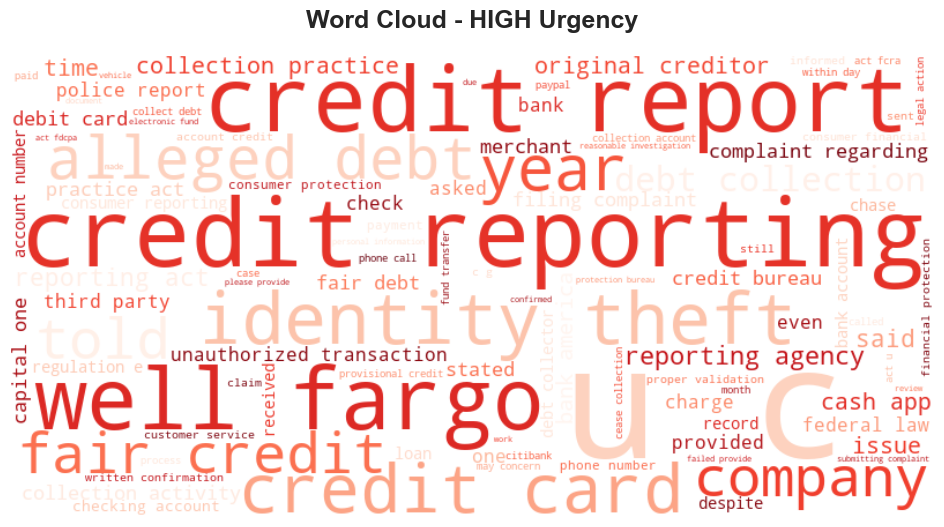

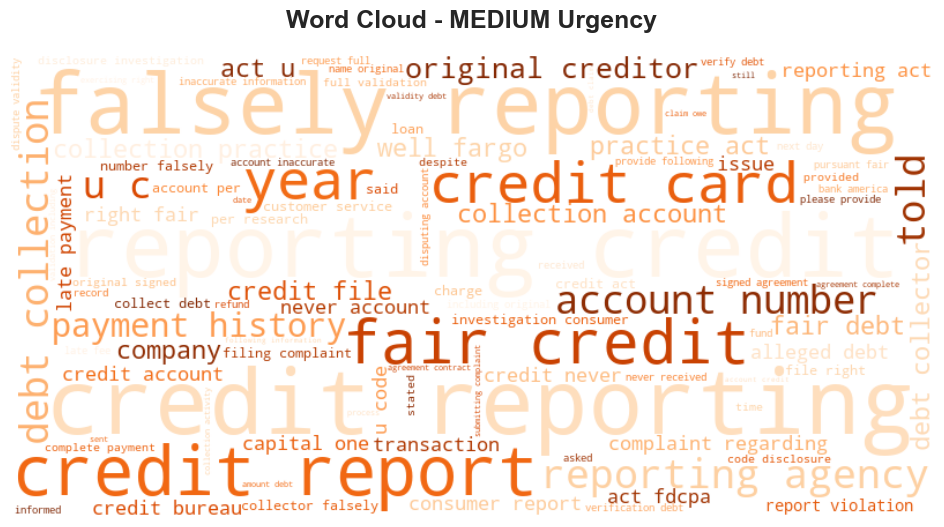

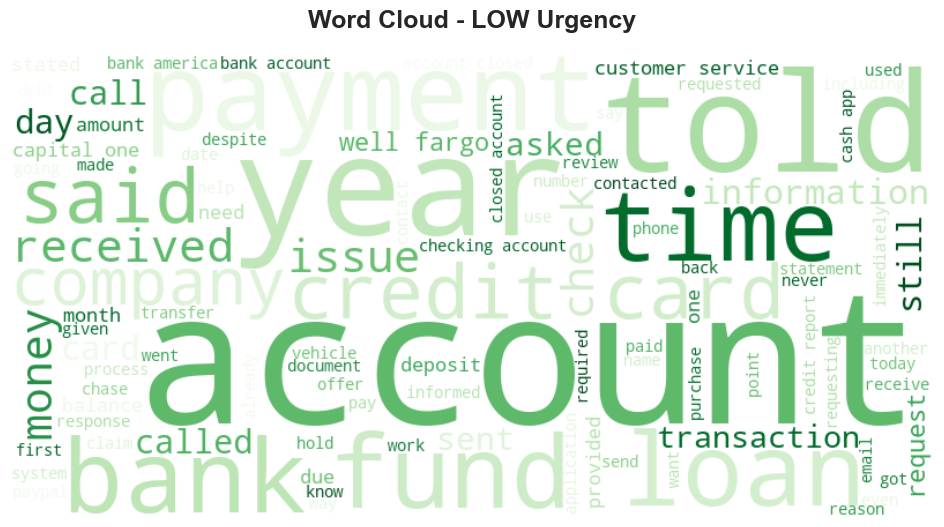

In [42]:
from wordcloud import WordCloud

# Fungsi untuk membuat dan memplot Word Cloud
def plot_wordcloud(text_series, title, colormap):
    # Menggabungkan semua baris teks menjadi satu paragraf raksasa
    text = " ".join(text_series.astype(str))
    
    # Membuat WordCloud dengan parameter visual
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap=colormap, 
                          max_words=100,
                          contour_width=3, 
                          contour_color='steelblue').generate(text)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.show()

# Mengeksekusi Word Cloud dengan warna yang mencerminkan urgensi
print("Memproses Word Cloud...")
plot_wordcloud(high_texts, 'Word Cloud - HIGH Urgency', 'Reds')
plot_wordcloud(medium_texts, 'Word Cloud - MEDIUM Urgency', 'Oranges')
plot_wordcloud(low_texts, 'Word Cloud - LOW Urgency', 'Greens')

## 7. Menyimpan Data Bersih (Final Dataset)
Membuat *subset* dataset (Hanya berisi Fitur dan Label Target) kemudian menyimpannya ke `.csv` baru agar di tahapan *Training* (Notebook berikutnya).

In [43]:
# Kita akan memfokuskan dataframe pada kolom yang diperlukan saja untuk training
df_final = df[['Cleaned_Narrative', 'Urgency']].copy()

# Hapus jika setelah dibersihkan teksnya menjadi benar-benar kosong
df = df[df['Cleaned_Narrative'] != '']

# Aktifkan baris di bawah untuk menyimpan file
# df_final.to_csv('../data/processed/cleaned_complaints.csv', index=False)

print(f"Final dataset shape ready for training: {df_final.shape}")
df_final.head()

Final dataset shape ready for training: (53928, 2)


,Cleaned_Narrative,Urgency
0,started getting email telephone call company called bureau telling owe past automobile repossessed lender time told not owe anything would report underwater amount credit bureau told would not send collection,Low
1,date ref bal ep audit continued contact cease desist notice intent pursue legal action letter serf formal notice continued attempt contact receiving written cease desist demand dated constitute unlawful unwanted communication correspondence clearly advised following separated company question company not operational since not owner operator responsible party company no authority act behalf business contact directed toward regarding company must cease immediately despite receiving notice proceeded continue contacting direct violation demand specifically additional email sent phone call made additional contact attempt made action constitute knowing repeated unwanted contact person commits harassment intentionally harass annoy another person repeated unwanted contact continuing communication clear demand cease contact evidence intentional harassment additionally oregon law recognizes civil liability persistent unwanted contact interference personal privacy peace oregon court held repeated unwanted communication notice stop may support claim including harassment invasion privacy intentional infliction emotional distress see recognizing civil liability conduct intentionally intrudes upon anothers protected interest clear notice continued communication also demonstrate disregard lawful written demand cease contact non related private individual establishes willful nature conduct accordingly hereby placed final notice following not affiliated company referenced communication no authority obligation regarding business insurance matter future communication regarding company must directed company legal representative immediately cease communication contact occurs receipt letter pursue available legal remedy including filing civil action seeking injunctive relief monetary damage attorney fee relief court deems appropriate continued communication documented preserved evidence letter serf final opportunity comply voluntarily legal action initiated govern accordingly sincerely,High
2,approached group people outside local grocery store asking donation help sick child showed donation information sheet looked official offered donate showed screen displayed handed credit card processing tried card time card reader attached phone told didnt work asked another card could try ended trying card said went struggling card one asked could pull square reader website phone asked could login stupidly handed phone let login think didnt want see fraud notification came running card going filling name donation amount email sheet could send receipt sheet appeared numerous donation guess make seem legit distract feel stupid fallen thought trying help child need done returned home didnt realize problem later day bank started sending fraud notification multiple charge coming thousand dollar let bank know not recognize transaction two three bank took care problem no issue bank america however denied fraud claim chip read pin entered signed merchandise mean someone allowed use card present separate charge bank america allowed go totaling fraudulent charge called filed police report filed complaint ftc reopened fraud claim bank america explaining happened providing police report number ftc complaint number also sent letter information claim denied exact reason chip read pin entered signed merchandise mean someone allowed use card present im not sure else logic provide credit card pay dinner restaurant server run charge phone away card apparently bank america think authorized use not fraud physical card absolutely ridiculous bank given trouble issue,High
3,citi bank best buy card account ending unknowingly auto renewed fee applied accrued immediately upon discovery account fee account closed paid best buy prorated paid remain